In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

In [2]:
# oni = pd.read_csv("nino34_mean.csv",index_col=0,date_parser=lambda x: pd.to_datetime(x,format='%Y-%m-%d'),header=None).iloc[10:-1,0]
# oni_pd = oni
# oni = oni.to_numpy().flatten()
# oni.shape
# oni_pd.shape


In [21]:
#gmst = pd.read_csv("./data/gmst.csv",header=None,index_col=0)
gmst = pd.read_excel("./OHC处理.xlsx",header=0,index_col=0,names=['OHC'],date_parser=lambda x: pd.to_datetime(x,format='%Y'))
#gmst = gmst["1870":"2025"]
gmst_index = pd.to_datetime(gmst.index,format='%Y')

gmst = gmst.iloc[:,0].to_numpy().flatten()
gmst.shape
gmst_index

C:\Users\34723\AppData\Local\Temp\ipykernel_31364\856132108.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  gmst = pd.read_excel("./OHC处理.xlsx",header=0,index_col=0,names=['OHC'],date_parser=lambda x: pd.to_datetime(x,format='%Y'))


DatetimeIndex(['1940-01-01', '1941-01-01', '1942-01-01', '1943-01-01',
               '1944-01-01', '1945-01-01', '1946-01-01', '1947-01-01',
               '1948-01-01', '1949-01-01', '1950-01-01', '1951-01-01',
               '1952-01-01', '1953-01-01', '1954-01-01', '1955-01-01',
               '1956-01-01', '1957-01-01', '1958-01-01', '1959-01-01',
               '1960-01-01', '1961-01-01', '1962-01-01', '1963-01-01',
               '1964-01-01', '1965-01-01', '1966-01-01', '1967-01-01',
               '1968-01-01', '1969-01-01', '1970-01-01', '1971-01-01',
               '1972-01-01', '1973-01-01', '1974-01-01', '1975-01-01',
               '1976-01-01', '1977-01-01', '1978-01-01', '1979-01-01',
               '1980-01-01', '1981-01-01', '1982-01-01', '1983-01-01',
               '1984-01-01', '1985-01-01', '1986-01-01', '1987-01-01',
               '1988-01-01', '1989-01-01', '1990-01-01', '1991-01-01',
               '1992-01-01', '1993-01-01', '1994-01-01', '1995-01-01',
      

In [23]:
oni = pd.read_csv("nino34_mean.csv",index_col=0,date_parser=lambda x: pd.to_datetime(x,format='%Y-%m-%d'),header=None)
oni = oni['1940':'2024']
oni_pd = oni
oni = oni.to_numpy().flatten()
oni.shape
oni_pd.shape
oni_pd.index = gmst_index




C:\Users\34723\AppData\Local\Temp\ipykernel_31364\2126617027.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  oni = pd.read_csv("nino34_mean.csv",index_col=0,date_parser=lambda x: pd.to_datetime(x,format='%Y-%m-%d'),header=None)


## 拟合 $ y = ax+b $

In [24]:
coff_x = np.polyfit(oni,gmst,1)

### 再对gmst拟合

In [25]:
coff_gmst  = np.polyfit(np.arange(len(gmst)),gmst,1)

In [26]:
gmst_hat = np.poly1d(coff_x)
gmst_hat_self = np.poly1d(coff_gmst)
gmst_self_ll = gmst_hat_self(np.arange(len(gmst)))
gmst_pre = gmst_hat(oni_pd)
gmst_pre = gmst_pre.flatten()
gmst_self = gmst - gmst_self_ll
gmst_pre.shape

(85,)

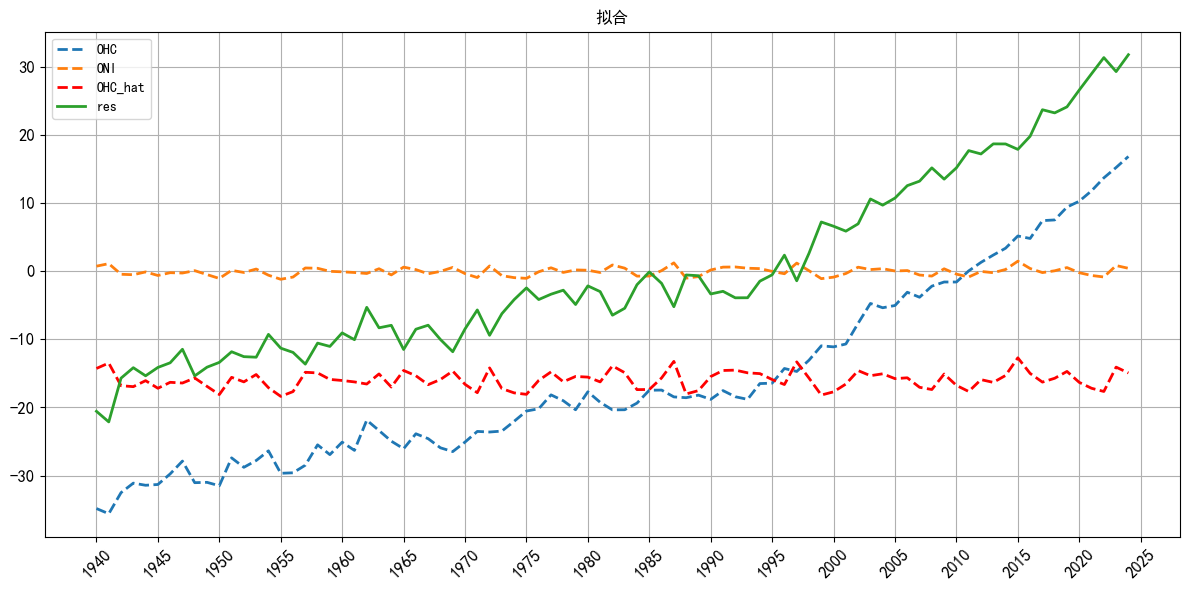

In [27]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
fig,ax = plt.subplots(1,1,figsize=(12
                    ,6))
ax.plot(gmst_index,gmst, "--",lw = 2.0,label = 'OHC')
ax.plot(gmst_index,oni_pd, "--",lw = 2.0,label = 'ONI')
ax.plot(gmst_index,gmst_pre,'r--',lw = 2.0,label = 'OHC_hat')
res= gmst-gmst_pre
ax.plot(gmst_index,res,'-',lw = 2.0,label = 'res')
#ax.plot(gmst_index,gmst_self,'-',lw = 2.0,label = 'gmst_self')
ax.legend(loc = "best")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.tick_params(axis='x', rotation=45)
ax.set_title("拟合")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.grid()
plt.show()

## 相关系数

In [9]:

y_cor= np.corrcoef(oni[:-1],gmst_self[1:])

In [10]:
y_cor

array([[1.        , 0.43568211],
       [0.43568211, 1.        ]])

## 计算 $\hat{y}-y$

In [28]:
res = gmst[:] - gmst_hat(oni)[:]

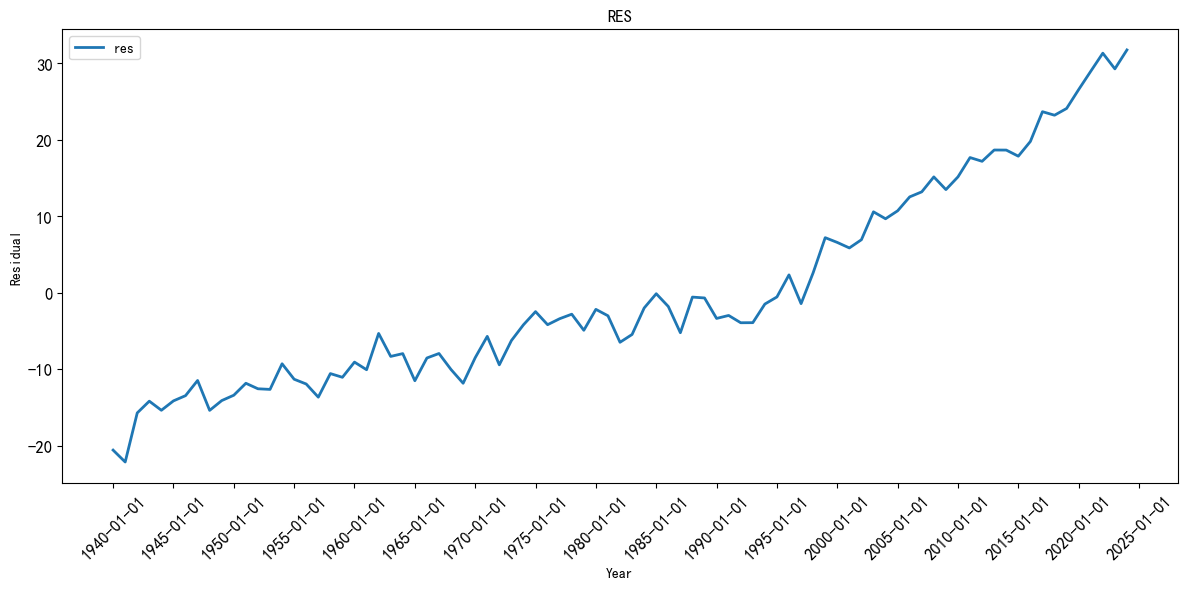

In [29]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
fig,ax = plt.subplots(1,1,figsize=(12
                    ,6))
# ax.plot(oni_pd.index,gmst, "--",lw = 2.0,label = 'gmst')
# ax.plot(oni_pd.index,oni_pd, "--",lw = 2.0,label = 'ONI')
# ax.plot(oni_pd.index,gmst_pre,'r--',lw = 2.0,label = 'gmst_hat')
#res= gmst-gmst_pre
ax.plot(gmst_index,res,'-',lw = 2.0,label = 'res')
ax.legend(loc = "best")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Residual")
ax.set_title("RES")
# 设置x轴为时间序列时每隔5年显示一次
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

In [30]:
gmst_index = pd.date_range(start='1940-01-01', end='2024-01-01', freq='YS')

In [31]:
gmst_bynoi = pd.DataFrame(res,index=gmst_index,columns=['res'])
gmst_bynoi.to_csv('./data/OHC_bynoi.csv', header=False)